<a href="https://colab.research.google.com/github/Aryan-core/HASP-Drexel/blob/fix-timestamp-alignment/DataloggerProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
class Datalogger_Processing:
    def __init__(self, filepath):
      '''
      Class for processing datalogger files

      Arg:
        filepath: string of filepath to datalogger CSV
      '''
      self.fp = filepath

      self.fp_string = self.fp.split('/')[-1]

      self.df = pd.read_csv(self.fp)


    def subplots(self, xaxis='Timer[S]', title=None):
      '''
      Method for subplots of datalogger data

      Args:
        Columns
      '''
      if title is None:
          title = self.fp_string

      fig1, axes = plt.subplots(1, 3, figsize=(20, 5))

      axes[0].plot(self.df[xaxis], self.df['Events CW1&2'], marker='o', markersize=0.7, color='blue', label="CW 1 & 2")
      axes[0].plot(self.df[xaxis], self.df['Events CW1&2&3'], marker='o', markersize=0.7, color='magenta', label="CW 1 & 2 & 3")
      axes[0].set_xlabel(xaxis)
      axes[0].set_ylabel('Events')
      axes[0].legend()
      axes[0].set_title('CosmicWatch Events over Time')

      axes[1].plot(self.df[xaxis], self.df['Pressure[Pa]'], marker='o', markersize=0.7, color='green', label="Pressure")
      axes[1].set_xlabel(xaxis)
      axes[1].set_ylabel('Pressure[Pa]')
      axes[1].legend()
      axes[1].set_title('Pressure over Time')

      axes[2].plot(self.df[xaxis], self.df['Temperature[C]'], marker='o', markersize=0.7, color='red', label="Temperature")
      axes[2].set_xlabel(xaxis)
      axes[2].set_ylabel('Temperature[C]')
      axes[2].legend()
      axes[2].set_title('Temperature over Time')

      plt.suptitle(title)
      plt.show()

    def separate_timer_resets(self, plotting_title=None):
      '''
      Detect any timer resets in the datalogger data, and creates separate DataFrames for each run. Then creates an Absolute Timer column to add to the dataframe, and plots the data as a function of the absolute timer.
      '''
      if plotting_title is None:
          plotting_title = self.fp_string

      self.df_sorted = self.df.copy().sort_index().reset_index(drop=True)                      # make sure rows are in original order + give clean 0-based index

      time_col = 'Timer[S]'                                                    # name of the column that holds the timer values

      reset_mask = self.df_sorted[time_col].diff() < -10                                # .diff() computes row-to-row differences; this creates a boolean mask that's True wherever the time decreased by more than 3 seconds (negative value indicates a reset/jump backward)

      new_segment_starts = [0] + (reset_mask[reset_mask].index).tolist()   # list of row numbers where each new segment begins: 0 + (index of each True + 1 to point to first row of next segment)
      print(f"Detected {len(new_segment_starts)-1} separate timer reset(s) at rows {new_segment_starts}")

      self.timerreset_segments = []                                                            # empty list that will store one DataFrame per continuous run

      for i in range(len(new_segment_starts)):                                 # loop over each detected starting point
        start = new_segment_starts[i]                                        # determine starting row index of current segment; store in "start"
        end = new_segment_starts[i+1] if i+1 < len(new_segment_starts) else None   # ending row = start of next segment, or None (means go to end of DataFrame)
        seg = self.df_sorted.iloc[start:end].copy()                                  # slice out this segment and make independent copy; iloc
        seg['Timer_rel'] = seg[time_col] - seg[time_col].iloc[0]             # add relative time column that starts at ~0 for this run
        self.timerreset_segments.append(seg)                                                 # store this segment in the list

      for i, seg in enumerate(self.timerreset_segments, 1):
        t_min = seg[time_col].min()
        t_max = seg[time_col].max()
        nrows = len(seg)
        print(f"  Run {i:2d}: {nrows:5d} rows, timer {t_min:6.0f} → {t_max:6.0f} s")

      self.create_absolute_timer()

      for i, start_idx in enumerate(new_segment_starts):
        print(f"\n--- Around start of Timer Reset {i+1} (row {start_idx}) ---")

        start = max(0, start_idx - 5)
        end   = start_idx + 6

        slice_df = self.df.iloc[start:end] # Changed from self.df_sorted to self.df

        print(slice_df[[time_col, 'Events CW1&2', 'Events CW1&2&3', 'Absolute Timer (S)']].to_string(index=True))

      self.subplots(xaxis='Absolute Timer (S)', title=plotting_title)


    def create_absolute_timer(self):
      '''
      Creates continuous Absolute Timer by chaining last value from before timer reset
      '''
      absolute_timers = []
      previous_end = 0.0

      for i, seg in enumerate(self.timerreset_segments):
        current_timers = seg['Timer[S]'].values

        if len(current_timers) == 0:
            continue

        absolute_this_segment = current_timers + previous_end

        absolute_timers.extend(absolute_this_segment)

        previous_end = absolute_this_segment[-1]

      self.df['Absolute Timer (S)'] = absolute_timers

## 0 Degrees Datalogger

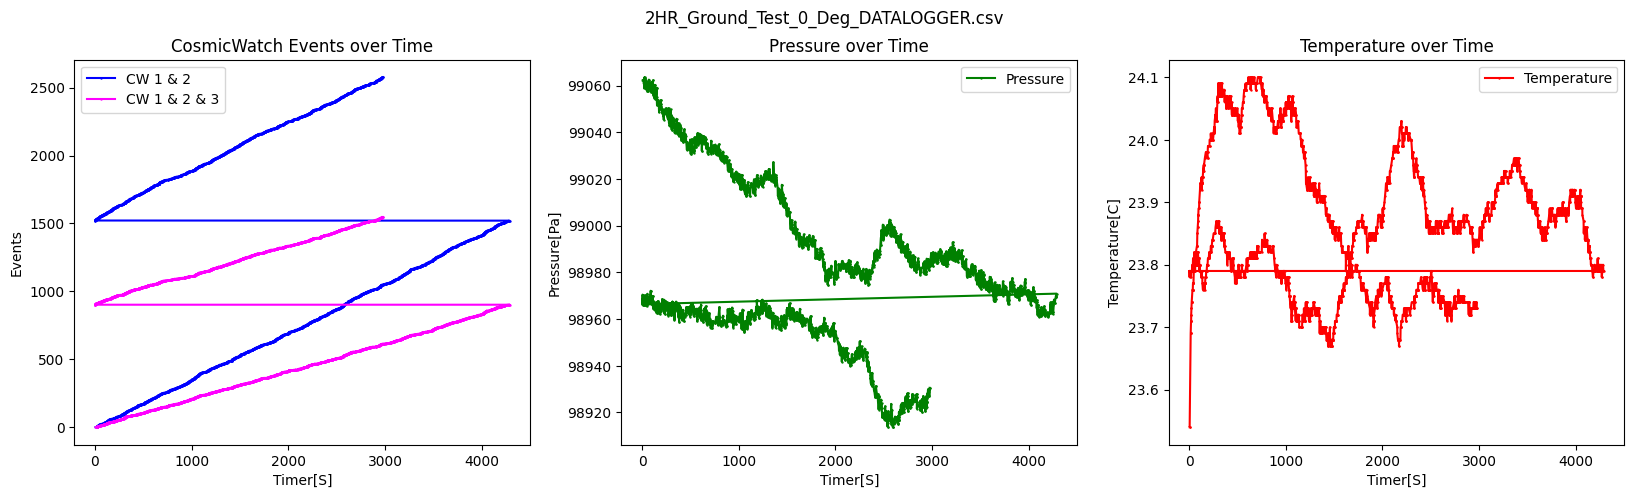

Detected 1 separate timer reset(s) at rows [0, 2423]
  Run  1:  2423 rows, timer      6 →   4289 s
  Run  2:  1702 rows, timer      2 →   2975 s

--- Around start of Timer Reset 1 (row 0) ---
    Timer[S]  Events CW1&2  Events CW1&2&3  Absolute Timer (S)
0   5.849609             1               0            5.849609
1   5.855468             1               1            5.855468
2  16.342773             2               1           16.342773
3  16.415039             3               1           16.415039
4  16.420898             3               2           16.420898
5  19.281250             4               2           19.281250

--- Around start of Timer Reset 2 (row 2423) ---
         Timer[S]  Events CW1&2  Events CW1&2&3  Absolute Timer (S)
2418  4269.168945          1518             901         4269.168945
2419  4281.617187          1519             901         4281.617187
2420  4286.391601          1520             901         4286.391601
2421  4286.411132          1520             9

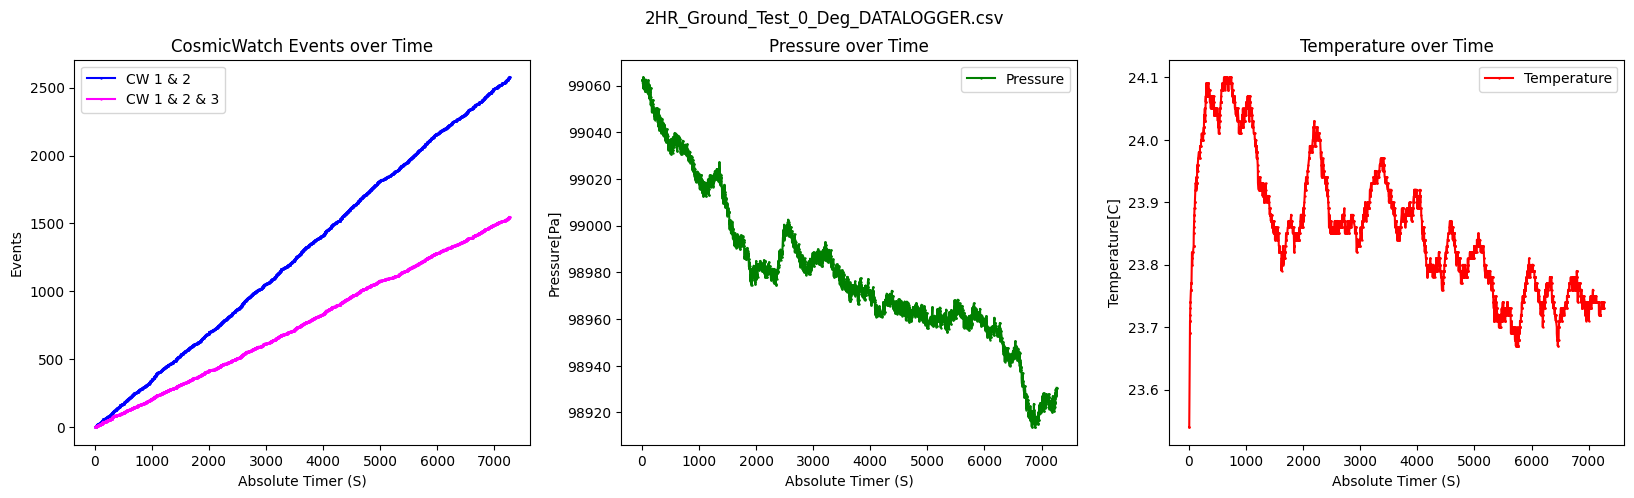

In [ ]:
csv_file_path1 = '/content/drive/MyDrive/2026_ Jan 15 (Ground Testing -- 45 deg)/2HR_Ground_Test_0_Deg_DATALOGGER.csv' # @param {type:"string"}
Datalogger_Processing(csv_file_path1).subplots()
Datalogger_Processing(csv_file_path1).separate_timer_resets()

## 45 Degrees Datalogger

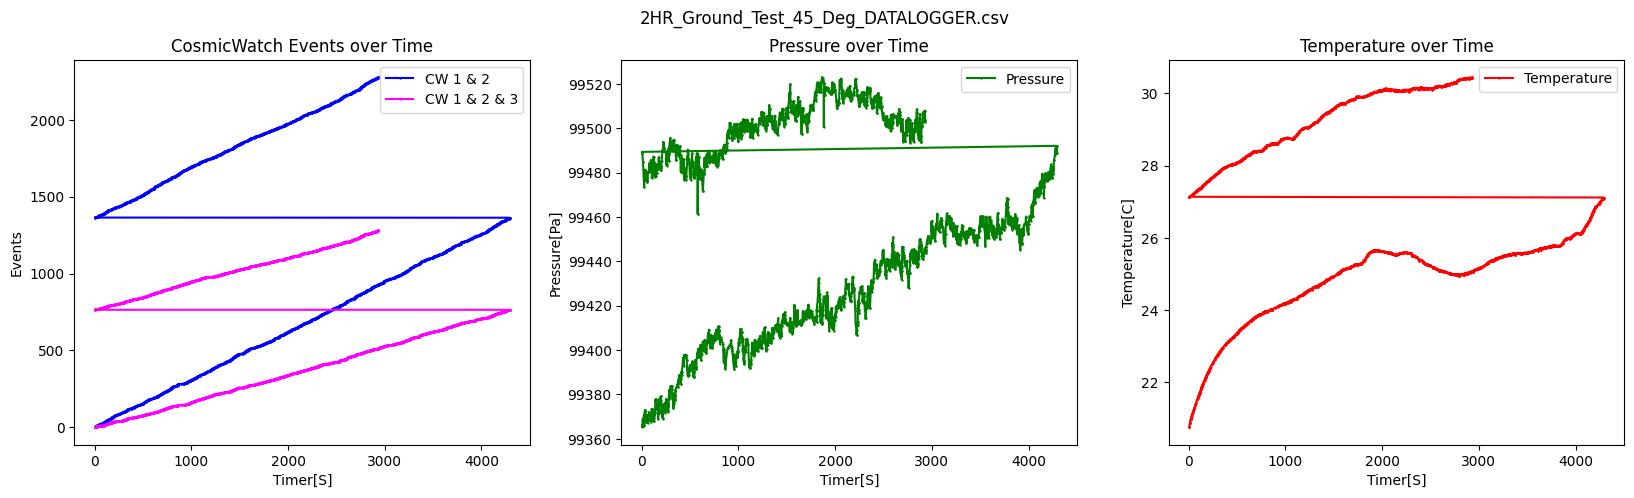

Detected 1 separate timer reset(s) at rows [0, 2127]
  Run  1:  2127 rows, timer      6 →   4291 s
  Run  2:  1430 rows, timer      5 →   2933 s

--- Around start of Timer Reset 1 (row 0) ---
    Timer[S]  Events CW1&2  Events CW1&2&3  Absolute Timer (S)
0   6.130859             1               0            6.130859
1   6.136718             1               1            6.136718
2   6.206054             2               1            6.206054
3  10.181640             3               1           10.181640
4  10.187500             3               2           10.187500
5  10.236328             4               2           10.236328

--- Around start of Timer Reset 2 (row 2127) ---
         Timer[S]  Events CW1&2  Events CW1&2&3  Absolute Timer (S)
2122  4287.176757          1361             762         4287.176757
2123  4290.532226          1362             762         4290.532226
2124  4290.551757          1362             763         4290.551757
2125  4290.670898          1363             7

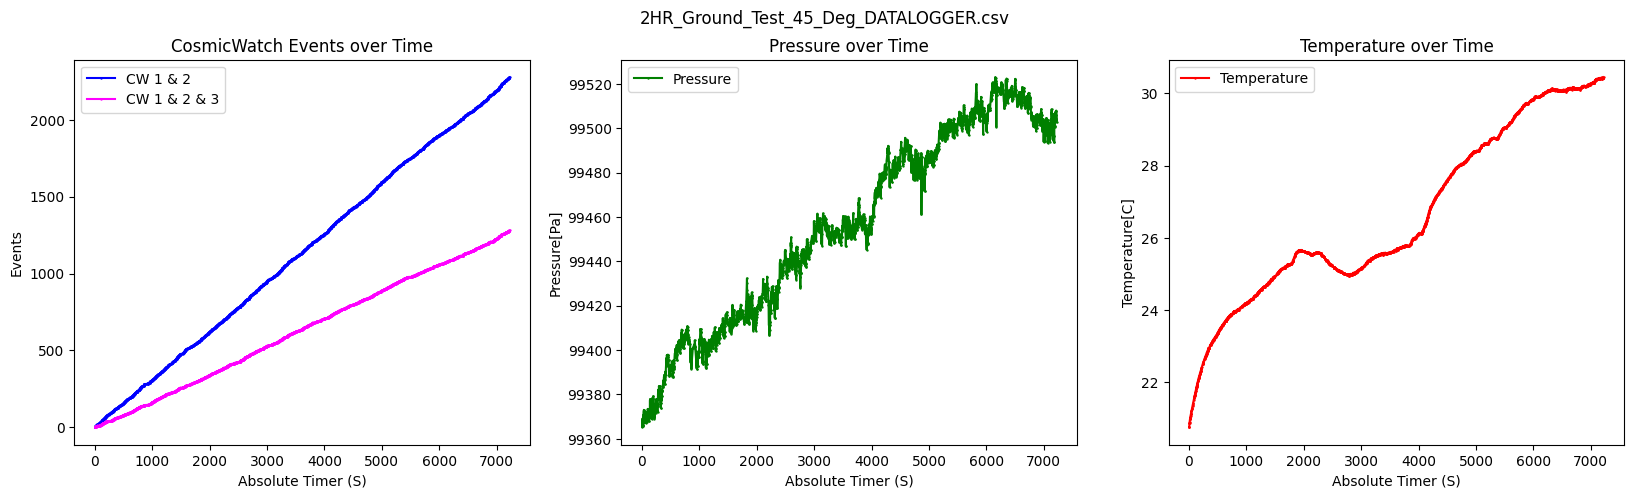

In [ ]:
csv_file_path2 = '/content/drive/MyDrive/2026_ Jan 15 (Ground Testing -- 45 deg)/2HR_Ground_Test_45_Deg_DATALOGGER.csv' # @param {type:"string"}
Datalogger_Processing(csv_file_path2).subplots()
Datalogger_Processing(csv_file_path2).separate_timer_resets()

Matched: 4125 / 4125 rows
Unmatched: 0 rows

Match offset stats (seconds):
count    4125.0000
mean        0.2703
std         0.2716
min         0.0000
25%         0.0746
50%         0.1836
75%         0.3817
max         1.9541
Name: dt_match[s], dtype: float64

Rows for plotting: 3596


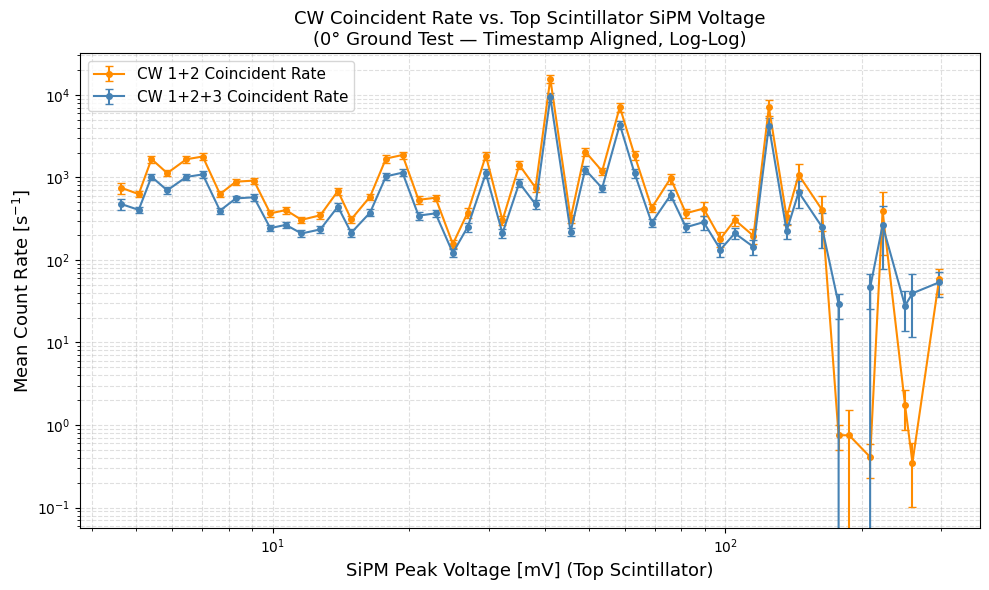

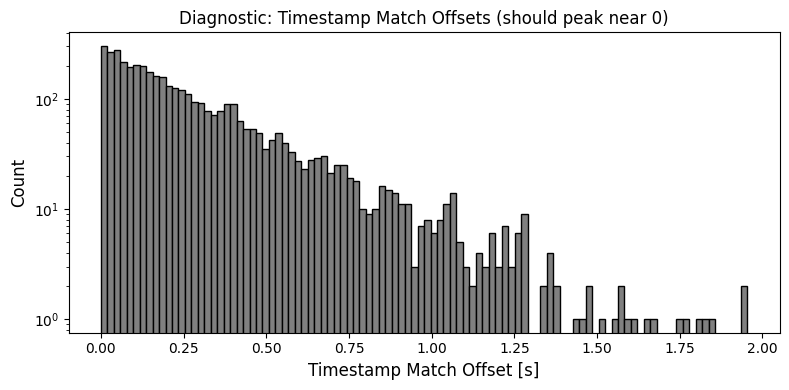

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


dl_df = pd.read_csv('/content/drive/MyDrive/2HR_Ground_Test_0_Deg_DATALOGGER.csv')


columns = ['Event','Time[s]','Coincident[bool]','ADC[0-4095]','SiPM[mV]','Deadtime[s]','Temp[C]','Pressure[Pa]']
top_df_raw = pd.read_csv(
    '/content/drive/MyDrive/2HR_Ground_Test_0_Deg_TOP.txt',
    sep='\t', comment='#', header=None, skiprows=3, names=columns, engine='python'
)


dl_df  = dl_df.sort_values('Timer[S]').reset_index(drop=True)
top_df = top_df_raw[['Time[s]','SiPM[mV]','ADC[0-4095]','Coincident[bool]']].copy()
top_df = top_df.rename(columns={'Time[s]': 'Time_top[s]'})
top_df = top_df.sort_values('Time_top[s]').reset_index(drop=True)


aligned = pd.merge_asof(
    dl_df, top_df,
    left_on='Timer[S]',
    right_on='Time_top[s]',
    direction='nearest',
    tolerance=5.0
)

n_matched = aligned['SiPM[mV]'].notna().sum()
n_total   = len(aligned)
print(f"Matched: {n_matched} / {n_total} rows")
print(f"Unmatched: {n_total - n_matched} rows")

aligned['dt_match[s]'] = (aligned['Timer[S]'] - aligned['Time_top[s]']).abs()
print(f"\nMatch offset stats (seconds):")
print(aligned['dt_match[s]'].describe().round(4))


aligned['delta_CW12']  = aligned['Events CW1&2'].diff().clip(lower=0).fillna(0)
aligned['delta_CW123'] = aligned['Events CW1&2&3'].diff().clip(lower=0).fillna(0)
aligned['delta_t']     = aligned['Timer[S]'].diff().clip(lower=0).fillna(0)

aligned['rate_CW12']  = np.where(aligned['delta_t'] > 0, aligned['delta_CW12']  / aligned['delta_t'], np.nan)
aligned['rate_CW123'] = np.where(aligned['delta_t'] > 0, aligned['delta_CW123'] / aligned['delta_t'], np.nan)

plot_df = aligned.dropna(subset=['SiPM[mV]','rate_CW12','rate_CW123']).copy()
plot_df = plot_df[(plot_df['rate_CW12'] > 0) | (plot_df['rate_CW123'] > 0)]
print(f"\nRows for plotting: {len(plot_df)}")


NUM_BINS  = 50
sipm_min  = max(plot_df['SiPM[mV]'].min(), 0.1)
sipm_max  = plot_df['SiPM[mV]'].max()
bin_edges = np.logspace(np.log10(sipm_min), np.log10(sipm_max), NUM_BINS + 1)

plot_df['mV_bin'] = pd.cut(plot_df['SiPM[mV]'], bins=bin_edges, include_lowest=True)

binned = plot_df.groupby('mV_bin', observed=True).agg(
    mean_mV       = ('SiPM[mV]',   'mean'),
    mean_rate_12  = ('rate_CW12',  'mean'),
    mean_rate_123 = ('rate_CW123', 'mean'),
    n_events      = ('SiPM[mV]',   'count'),
).reset_index()

binned['err_12']  = binned['mean_rate_12']  / np.sqrt(binned['n_events'].clip(lower=1))
binned['err_123'] = binned['mean_rate_123'] / np.sqrt(binned['n_events'].clip(lower=1))
binned = binned.dropna(subset=['mean_mV'])


fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(binned['mean_mV'], binned['mean_rate_12'],
            yerr=binned['err_12'], fmt='o-', color='darkorange',
            lw=1.5, markersize=4, label='CW 1+2 Coincident Rate', capsize=3)

ax.errorbar(binned['mean_mV'], binned['mean_rate_123'],
            yerr=binned['err_123'], fmt='o-', color='steelblue',
            lw=1.5, markersize=4, label='CW 1+2+3 Coincident Rate', capsize=3)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('SiPM Peak Voltage [mV] (Top Scintillator)', fontsize=13)
ax.set_ylabel(r'Mean Count Rate [s$^{-1}$]', fontsize=13)
ax.set_title('CW Coincident Rate vs. Top Scintillator SiPM Voltage\n(0° Ground Test — Timestamp Aligned, Log-Log)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, which='both', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.hist(aligned['dt_match[s]'].dropna(), bins=100, color='gray', edgecolor='black')
ax2.set_xlabel('Timestamp Match Offset [s]', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Diagnostic: Timestamp Match Offsets (should peak near 0)', fontsize=12)
ax2.set_yscale('log')
plt.tight_layout()
plt.show()